In [14]:
# --- 0. IMPORT LIBRARY ---
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

In [15]:
# --- 1. SETUP ---
# Load model terbaik Anda (Pilih EfficientNet atau ResNet)
MODEL_PATH = 'efficientnetv2s_best.h5' 
print(f"⏳ Sedang memuat model {MODEL_PATH}...")
model = load_model(MODEL_PATH)
print("✅ Model Siap!")

# Nama Kelas (Harus urut sesuai training)
CLASS_NAMES = ['Bacterial Leaf Blight', 'Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast']

⏳ Sedang memuat model efficientnetv2s_best.h5...
✅ Model Siap!


In [16]:
# --- 2. FUNGSI DETEKSI GRADE (DARI PREPROCESSING) ---
def get_severity(img_bgr):
    try:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

        # Range Warna Penyakit (Kuning/Coklat/Merah)
        lower_green = np.array([30, 40, 40]); upper_green = np.array([90, 255, 255])
        lower_dis1 = np.array([0, 40, 40]); upper_dis1 = np.array([30, 255, 255])
        lower_dis2 = np.array([150, 40, 40]); upper_dis2 = np.array([180, 255, 255])

        mask_green = cv2.inRange(hsv, lower_green, upper_green)
        mask_disease = cv2.inRange(hsv, lower_dis1, upper_dis1) + cv2.inRange(hsv, lower_dis2, upper_dis2)

        total_pixel = np.count_nonzero(mask_green) + np.count_nonzero(mask_disease)
        if total_pixel == 0: return 0, 0, mask_disease
        
        ratio = (np.count_nonzero(mask_disease) / total_pixel) * 100
        
        # PERBAIKAN LOGIKA GRADE: Dibuat saling berkesinambungan
        if ratio <= 0.0: grade = 0
        elif ratio <= 10.0: grade = 1    # Ringan ( >0 hingga 10 )
        elif ratio <= 25.0: grade = 2    # Sedang ( >10 hingga 25 )
        else: grade = 3                  # Berat ( >25 )
            
        return grade, ratio, mask_disease
    except:
        return 0, 0, None

In [17]:
# --- 3. FUNGSI PREDIKSI GABUNGAN ---
def predict_final(image_path):
    # A. Baca Gambar
    img = cv2.imread(image_path)
    if img is None:
        print("❌ Gambar tidak ditemukan!")
        return

    # B. Hitung Severity (Pakai OpenCV)
    grade, ratio, mask_penyakit = get_severity(img)
    
    # C. Prediksi Jenis Penyakit (Pakai Deep Learning)
    # Resize dulu ke 224x224 sesuai mulut model
    img_resized = cv2.resize(img, (224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0) # Jadi (1, 224, 224, 3)
    img_array = img_array / 255.0  # Normalisasi

    predictions = model.predict(img_array)
    class_idx = np.argmax(predictions[0])
    confidence = np.max(predictions[0])
    disease_name = CLASS_NAMES[class_idx]

    # Khusus Healthy, Grade otomatis 0
    if disease_name == 'Healthy Rice Leaf':
        grade = 0
        ratio = 0.0
        level = "Sehat"
    else:
        # Terjemahkan Grade ke Teks
        if grade == 0: level = "Sehat/Sangat Ringan"
        elif grade == 1: level = "Ringan (Mild)"
        elif grade == 2: level = "Sedang (Moderate)"
        elif grade == 3: level = "Berat (Severe)"

    # --- 4. TAMPILKAN HASIL ---
    plt.figure(figsize=(12, 5))
    
    # Gambar Asli
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Hasil Analisis:\n{disease_name} ({confidence*100:.1f}%)", fontsize=14, color='blue', fontweight='bold')
    plt.axis('off')
    
    # Masker Penyakit
    plt.subplot(1, 2, 2)
    plt.imshow(mask_penyakit, cmap='hot')
    plt.title(f"Tingkat Keparahan:\nGrade {grade} - {level}\nArea Infeksi: {ratio:.2f}%", fontsize=14, color='red', fontweight='bold')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("="*40)
    print(f"📝 LAPORAN DIAGNOSA")
    print(f"• Jenis Penyakit : {disease_name}")
    print(f"• Kepastian Model: {confidence*100:.2f}%")
    print(f"• Tingkat Keparahan: Grade {grade} ({level})")
    print(f"• Persentase Rusak : {ratio:.2f}% dari luas daun")
    print("="*40)

🔬 PENGUJIAN 10 SAMPEL GAMBAR (BALANCED)
📊 Distribusi sampel:
  - Bacterial Leaf Blight: Grade 1, 2, 3 (3 sampel)
  - Brown Spot          : Grade 1, 2, 3 (3 sampel)
  - Leaf Blast          : Grade 1, 2, 3 (3 sampel)
  - Healthy Rice Leaf   : Grade 0       (1 sampel)

📸 SAMPEL 01: Grade_1_aug_0_6144.jpg
--------------------------------------------------
1/1 [==============================] - 3s 3s/step


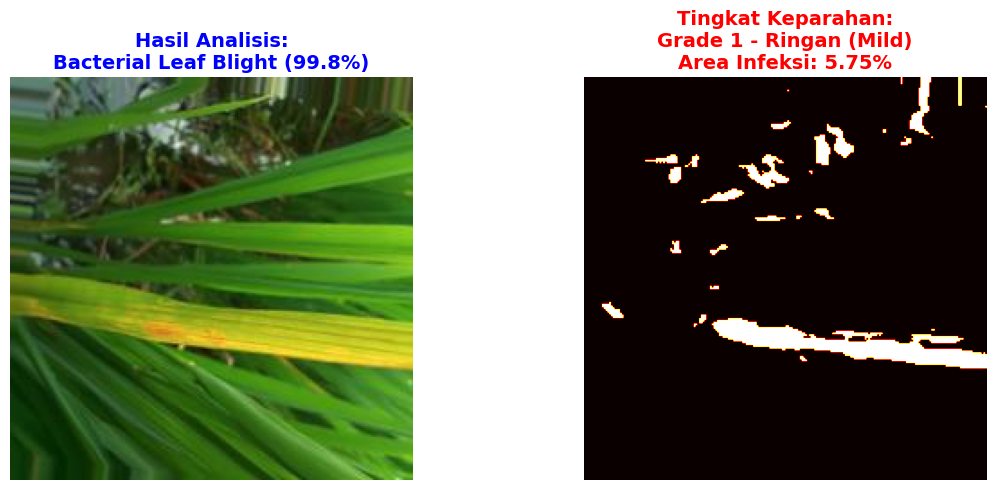

📝 LAPORAN DIAGNOSA
• Jenis Penyakit : Bacterial Leaf Blight
• Kepastian Model: 99.78%
• Tingkat Keparahan: Grade 1 (Ringan (Mild))
• Persentase Rusak : 5.75% dari luas daun

📸 SAMPEL 02: Grade_2_aug_0_213.jpg
--------------------------------------------------
1/1 [==============================] - 0s 48ms/step


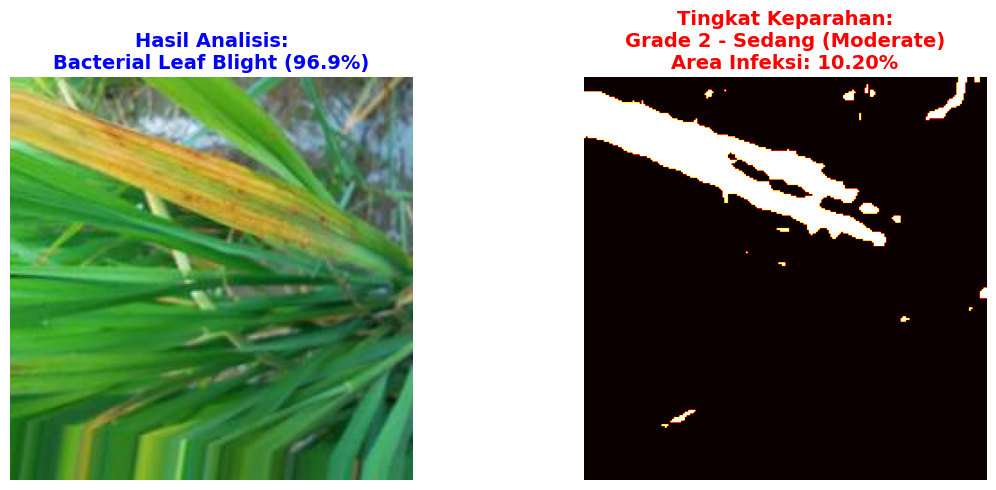

📝 LAPORAN DIAGNOSA
• Jenis Penyakit : Bacterial Leaf Blight
• Kepastian Model: 96.91%
• Tingkat Keparahan: Grade 2 (Sedang (Moderate))
• Persentase Rusak : 10.20% dari luas daun

📸 SAMPEL 03: Grade_3_aug_0_183.jpg
--------------------------------------------------
1/1 [==============================] - 0s 34ms/step


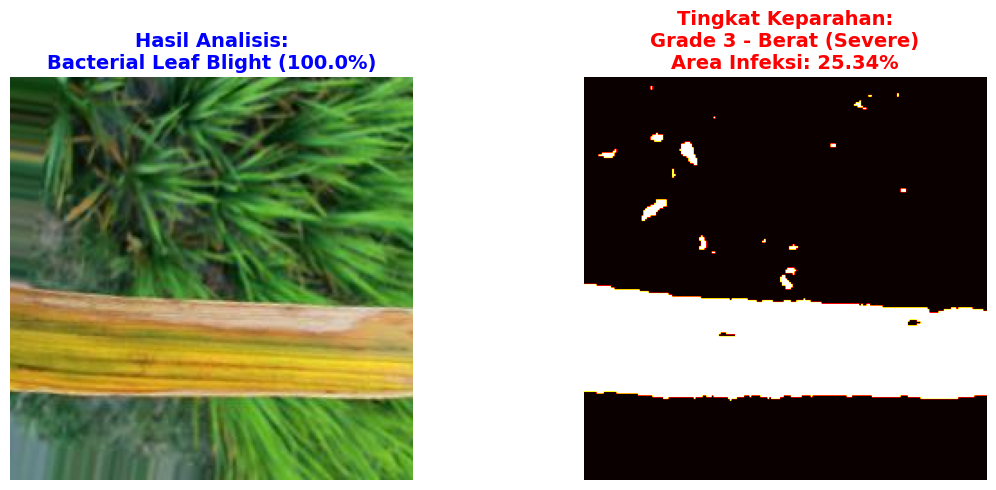

📝 LAPORAN DIAGNOSA
• Jenis Penyakit : Bacterial Leaf Blight
• Kepastian Model: 100.00%
• Tingkat Keparahan: Grade 3 (Berat (Severe))
• Persentase Rusak : 25.34% dari luas daun

📸 SAMPEL 04: Grade_1_aug_0_6379.jpg
--------------------------------------------------
1/1 [==============================] - 0s 41ms/step


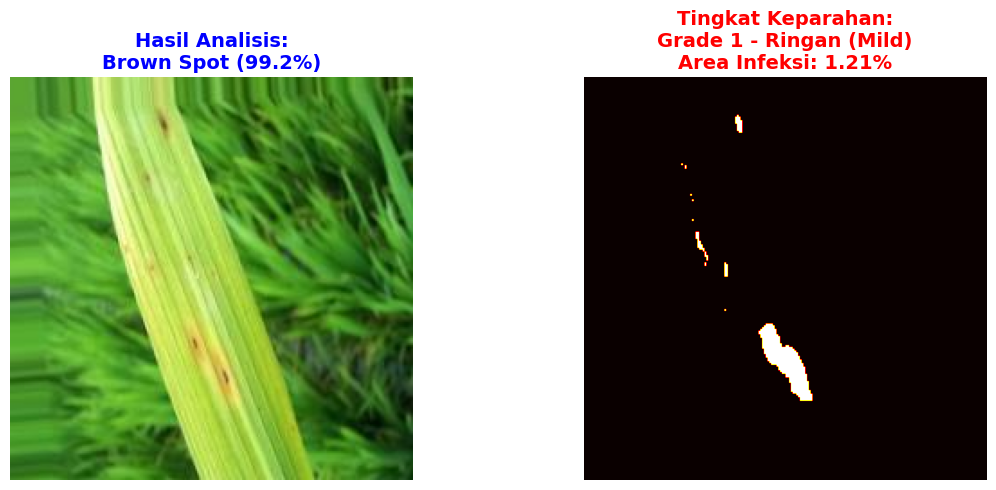

📝 LAPORAN DIAGNOSA
• Jenis Penyakit : Brown Spot
• Kepastian Model: 99.24%
• Tingkat Keparahan: Grade 1 (Ringan (Mild))
• Persentase Rusak : 1.21% dari luas daun

📸 SAMPEL 05: Grade_2_aug_0_5153.jpg
--------------------------------------------------
1/1 [==============================] - 0s 48ms/step


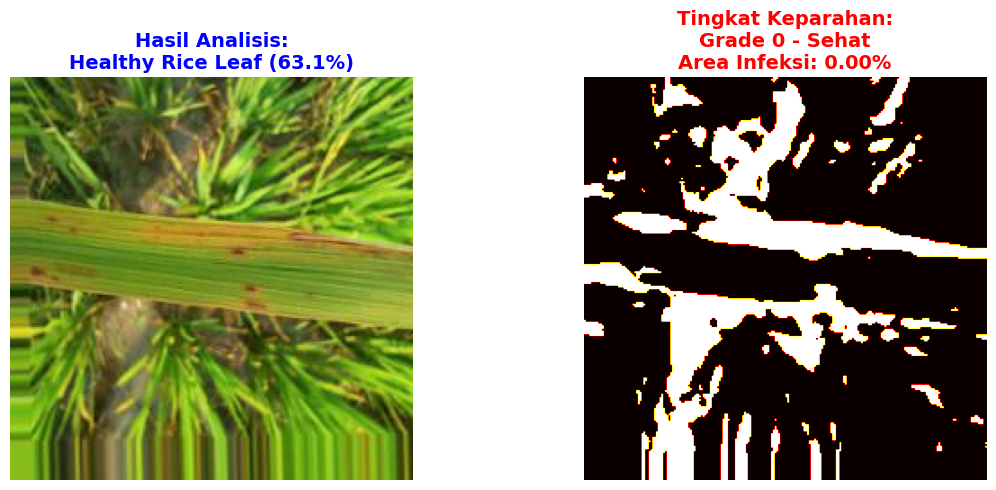

📝 LAPORAN DIAGNOSA
• Jenis Penyakit : Healthy Rice Leaf
• Kepastian Model: 63.11%
• Tingkat Keparahan: Grade 0 (Sehat)
• Persentase Rusak : 0.00% dari luas daun

📸 SAMPEL 06: Grade_3_aug_0_7317.jpg
--------------------------------------------------
1/1 [==============================] - 0s 43ms/step


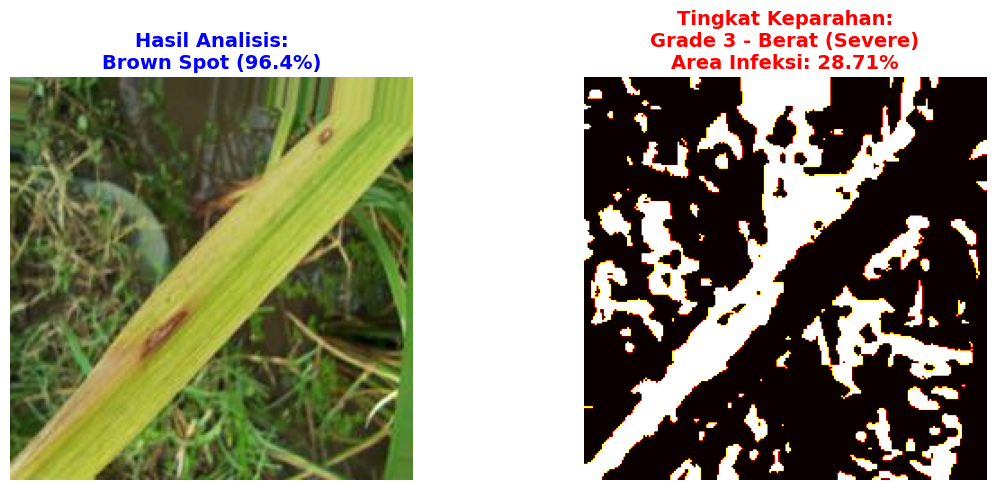

📝 LAPORAN DIAGNOSA
• Jenis Penyakit : Brown Spot
• Kepastian Model: 96.42%
• Tingkat Keparahan: Grade 3 (Berat (Severe))
• Persentase Rusak : 28.71% dari luas daun

📸 SAMPEL 07: Grade_1_aug_0_7003.jpg
--------------------------------------------------
1/1 [==============================] - 0s 36ms/step


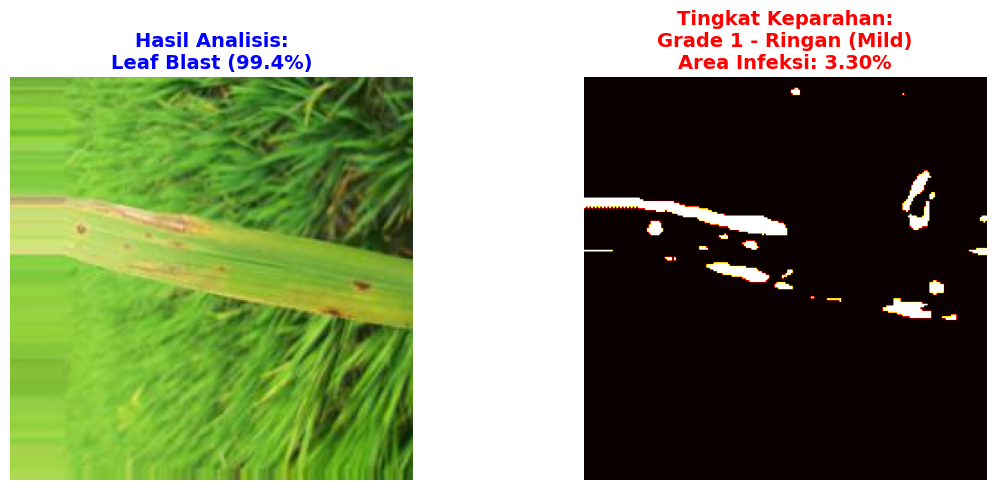

📝 LAPORAN DIAGNOSA
• Jenis Penyakit : Leaf Blast
• Kepastian Model: 99.40%
• Tingkat Keparahan: Grade 1 (Ringan (Mild))
• Persentase Rusak : 3.30% dari luas daun

📸 SAMPEL 08: Grade_2_aug_0_7108.jpg
--------------------------------------------------
1/1 [==============================] - 0s 40ms/step


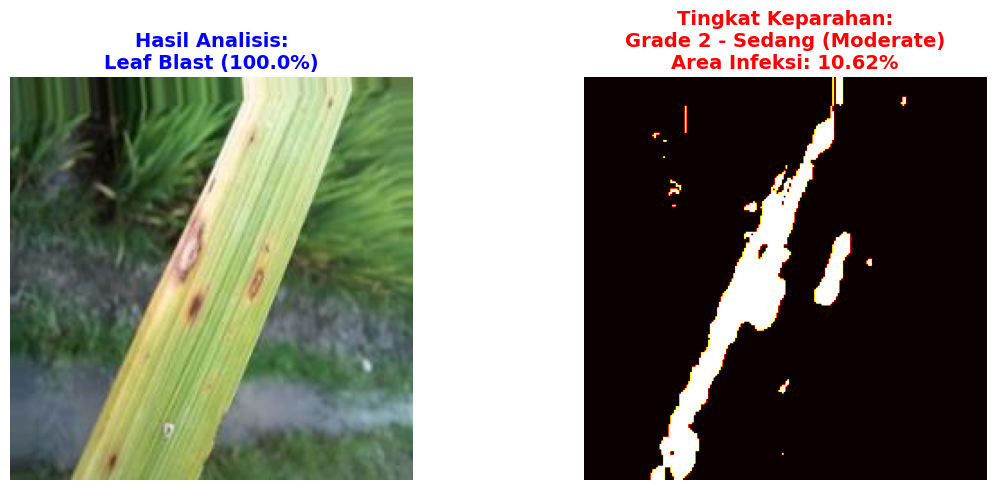

📝 LAPORAN DIAGNOSA
• Jenis Penyakit : Leaf Blast
• Kepastian Model: 99.96%
• Tingkat Keparahan: Grade 2 (Sedang (Moderate))
• Persentase Rusak : 10.62% dari luas daun

📸 SAMPEL 09: Grade_3_aug_0_6947.jpg
--------------------------------------------------
1/1 [==============================] - 0s 33ms/step


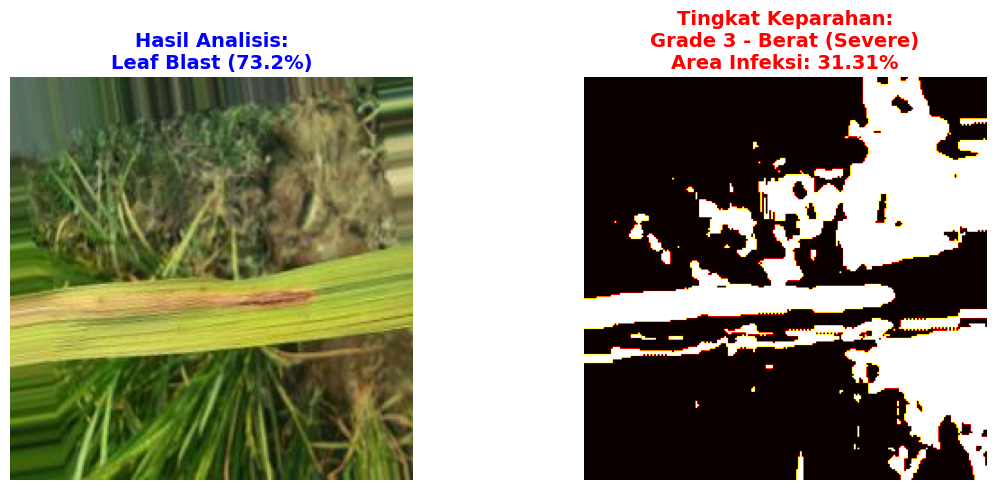

📝 LAPORAN DIAGNOSA
• Jenis Penyakit : Leaf Blast
• Kepastian Model: 73.23%
• Tingkat Keparahan: Grade 3 (Berat (Severe))
• Persentase Rusak : 31.31% dari luas daun

📸 SAMPEL 10: Grade_0_Healthy_rice_leaf (28).jpg
--------------------------------------------------
1/1 [==============================] - 0s 31ms/step


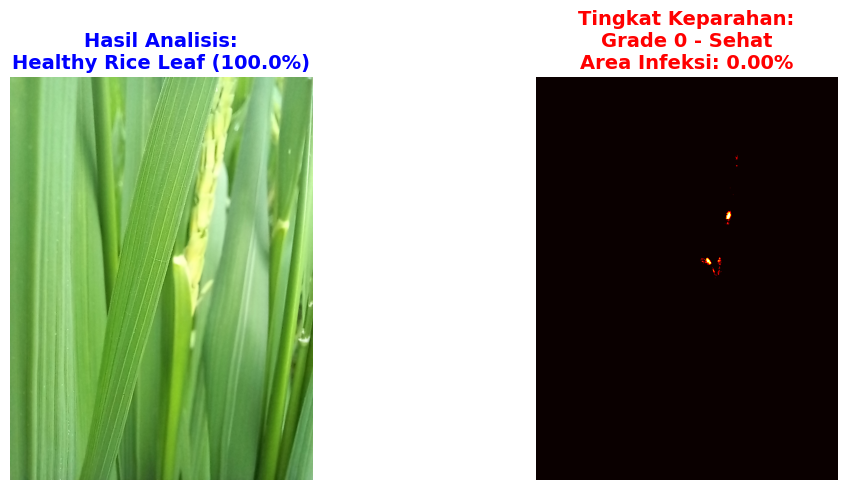

📝 LAPORAN DIAGNOSA
• Jenis Penyakit : Healthy Rice Leaf
• Kepastian Model: 99.99%
• Tingkat Keparahan: Grade 0 (Sehat)
• Persentase Rusak : 0.00% dari luas daun


In [ ]:
import glob
import os
import random

random.seed(42)

targets = [
    ('Bacterial Leaf Blight', 'Grade_1'),
    ('Bacterial Leaf Blight', 'Grade_2'),
    ('Bacterial Leaf Blight', 'Grade_3'),
    ('Brown Spot', 'Grade_1'),
    ('Brown Spot', 'Grade_2'),
    ('Brown Spot', 'Grade_3'),
    ('Leaf Blast', 'Grade_1'),
    ('Leaf Blast', 'Grade_2'),
    ('Leaf Blast', 'Grade_3'),
    ('Healthy Rice Leaf', 'Grade_0'),
]

test_images = []
for class_name, grade in targets:
    # Cari file yang cocok dengan grade tertentu
    pattern = f"Rice_Leaf_AUG_split/test/{class_name}/{grade}*.*"
    files = [f for f in glob.glob(pattern) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if files:
        # Ambil 1 file ACAK dari yang cocok
        test_images.append(random.choice(files))
    else:
        # Fallback: ambil gambar acak dari kelas tersebut
        fallback = f"Rice_Leaf_AUG_split/test/{class_name}/*.*"
        fallback_files = [f for f in glob.glob(fallback) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if fallback_files:
            test_images.append(random.choice(fallback_files))
        else:
            print(f"\u26a0\ufe0f Peringatan: Gambar untuk {class_name} ({grade}) tidak ditemukan!")

print(f"\U0001f52c PENGUJIAN {len(test_images)} SAMPEL GAMBAR (BALANCED)")
print("="*50)
print("\U0001f4ca Distribusi sampel:")
print("  - Bacterial Leaf Blight: Grade 1, 2, 3 (3 sampel)")
print("  - Brown Spot          : Grade 1, 2, 3 (3 sampel)")
print("  - Leaf Blast          : Grade 1, 2, 3 (3 sampel)")
print("  - Healthy Rice Leaf   : Grade 0       (1 sampel)")
print("="*50)

for i, img_path in enumerate(test_images, 1):
    print(f"\n\U0001f4f8 SAMPEL {i:02d}: {os.path.basename(img_path)}")
    print("-"*50)
    if os.path.exists(img_path):
        predict_final(img_path)
    else:
        print(f"\u274c File tidak ditemukan: {img_path}")